In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<font size="5" color="black">ch14_웹 데이터 수집_1</font>
***

# 1. BeautifulSoup / parser
    (정적 웹크롤링, 공공 api 사용)

`pip install bs4` (아나콘다 설치 시 자동으로 설치되는 패키지에 포함됨)


▪ 공식 사이트 : https://www.crummy.com/software/BeautifulSoup/ <br>
▪ Documentation : https://www.crummy.com/software/BeautifulSoup/bs4/doc/

- requests 라이브러리
    - requests.get(url, headers=..., params=...): 서버에 페이지 요청을 보냄
    - headers: '크롬 브라우저'라고 신분 위장 (403/406 차단 방지)
    - params: 검색어, 페이지 번호 등 URL 쿼리 전달
    - response.status_code: 접속 응답 상태 확인 (200: 성공, 403/406: 차단, 404: 없음)
    - response.text: 서버가 넘겨준 웹페이지의 전체 HTML 원본 텍스트

In [3]:
import requests # HTTP 요청을 처리하는 라이브러리

from requests_file import FileAdapter

In [5]:
# 로컬 파일을 웹요청 하듯이 읽어오는 작업
s = requests.Session()
s.mount("file://", FileAdapter()) # file://로 시작하는 url을 어댑처로 처리
response = s.get("file:///ai/source/01_python/data/ch14_sample.html") # c:ai/source/01_python/data/ch14_sample.html
response

<Response [200]>

In [6]:
if response:
    print('해당 url에 접근함')
else:
    print('url 접근 거부됨')

해당 url에 접근함


In [7]:
response.status_code
# 200 : 정상, 404 : 없는 페이지

200

In [9]:
response.content # html의 디코딩되지 않은 순수 바이너리(bytes) 데이터

b'<!DOCTYPE html>\r\n<html lang="en">\r\n<head>\r\n  <meta charset="UTF-8">\r\n</head>\r\n<body>\r\n  <h1 class="greeting css" id="text">Hello, CSS</h1>\r\n  <h1 class="css">Hi, CSS</h1>\r\n  <div id="subject">subject \xec\x84\xa0\xed\x83\x9d\xec\x9e\x90 \xec\x95\x88\xec\x9d\x98 \xeb\x82\xb4\xec\x9a\xa9</div>\r\n  <p>CSS \xec\x84\xa0\xed\x83\x9d\xec\x9e\x90\xeb\x8a\x94 \xeb\x8b\xa4\xec\x96\x91\xed\x95\x9c \xea\xb3\xb3\xec\x97\x90\xec\x84\x9c \xed\x99\x9c\xec\x9a\xa9\xeb\x90\xa9\xeb\x8b\x88\xeb\x8b\xa4</p>\r\n  <div class="contents">\r\n    \xec\x84\xa0\xed\x83\x9d\xec\x9e\x90\xeb\xa5\xbc \xec\x96\xb4\xeb\x96\xbb\xea\xb2\x8c \xec\x9e\x91\xec\x84\xb1\xed\x95\x98\xeb\x8a\x90\xeb\x83\x90\xec\x97\x90 \xeb\x94\xb0\xeb\x9d\xbc\r\n    <span>\xeb\x8b\xa4\xeb\xa5\xb8<b>\xec\x9a\x94\xec\x86\x8c\xea\xb0\x80 \xeb\xb0\x98\xed\x99\x98</b></span>\xeb\x90\xa9\xeb\x8b\x88\xeb\x8b\xa4\r\n  </div>\r\n  <div>CSS \xec\x84\xa0\xed\x83\x9d\xec\x9e\x90\xeb\x8a\x94 \xeb\x8b\xa4\xec\x96\x91\xed\x95\x9c \xea\xb3\

In [10]:
print(response.content.decode('utf-8'))

<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
</head>
<body>
  <h1 class="greeting css" id="text">Hello, CSS</h1>
  <h1 class="css">Hi, CSS</h1>
  <div id="subject">subject 선택자 안의 내용</div>
  <p>CSS 선택자는 다양한 곳에서 활용됩니다</p>
  <div class="contents">
    선택자를 어떻게 작성하느냐에 따라
    <span>다른<b>요소가 반환</b></span>됩니다
  </div>
  <div>CSS 선택자는 다양한 곳에 <b>활용</b>됩니다</div>
</body>
</html>


In [11]:
response.text

'<!DOCTYPE html>\r\n<html lang="en">\r\n<head>\r\n  <meta charset="UTF-8">\r\n</head>\r\n<body>\r\n  <h1 class="greeting css" id="text">Hello, CSS</h1>\r\n  <h1 class="css">Hi, CSS</h1>\r\n  <div id="subject">subject 선택자 안의 내용</div>\r\n  <p>CSS 선택자는 다양한 곳에서 활용됩니다</p>\r\n  <div class="contents">\r\n    선택자를 어떻게 작성하느냐에 따라\r\n    <span>다른<b>요소가 반환</b></span>됩니다\r\n  </div>\r\n  <div>CSS 선택자는 다양한 곳에 <b>활용</b>됩니다</div>\r\n</body>\r\n</html>'

In [14]:
# HTML 파싱 객체
from bs4 import BeautifulSoup
soup = BeautifulSoup(response.text, "html.parser")

# soup

In [15]:
# 1_soup.select_one('선택자') : 해당 선택자 중 첫 엘리먼트
el = soup.select_one('h1.greeting.css')

In [24]:
print('el : ', el)
print('el.text : ', el.text)
print('el.string : ', el.string)
print('el의 속성들 :', el.attrs)
print('el의 클래스 속성 :', el.attrs['class'])
print('el의 클래스 속성 :', el.attrs.get('class'))
print('el의 href 속성 :', el.attrs.get('href')) # get() : 데이터가 없을 경우 None 반환
print('el의 이름 :', el.name)

el :  <h1 class="greeting css" id="text">Hello, CSS</h1>
el.text :  Hello, CSS
el.string :  Hello, CSS
el의 속성들 : {'class': ['greeting', 'css'], 'id': 'text'}
el의 클래스 속성 : ['greeting', 'css']
el의 클래스 속성 : ['greeting', 'css']
el의 href 속성 : None
el의 이름 : h1


In [31]:
# 2_soup.select('선택자') : 해당 선택자 전체 엘리먼트 / 없을 경우 빈 list 반환
els = soup.select('h1.css')

In [36]:
print('el : ', els)
print('els.text : ',[el.text for el in els])
print('els.string : ',[el.string for el in els])
print('els의 속성들 : ',[el.attrs for el in els])
print('els의 클래스 속성들 : ',[el.attrs for el in els])
print('els의 이름들 : ',[el.name for el in els])

el :  [<h1 class="greeting css" id="text">Hello, CSS</h1>, <h1 class="css">Hi, CSS</h1>]
els.text :  ['Hello, CSS', 'Hi, CSS']
els.string :  ['Hello, CSS', 'Hi, CSS']
els의 속성들 :  [{'class': ['greeting', 'css'], 'id': 'text'}, {'class': ['css']}]
els의 클래스 속성들 :  [{'class': ['greeting', 'css'], 'id': 'text'}, {'class': ['css']}]
els의 이름들 :  ['h1', 'h1']


In [42]:
# 3_soup.find(태그, 속성) : 조건에 맞는 첫 번째 엘리먼트
print('soup.find :', soup.find('h1'),{'class':'css'})
print('soup.find :', soup.find('h1', class_='css'))
print()
print('select_one :', soup.select_one('h1#text'))
print('soup.find :', soup.find('h1',{'id':'text'}))

soup.find : <h1 class="greeting css" id="text">Hello, CSS</h1> {'class': 'css'}
soup.find : <h1 class="greeting css" id="text">Hello, CSS</h1>

select_one : <h1 class="greeting css" id="text">Hello, CSS</h1>
soup.find : <h1 class="greeting css" id="text">Hello, CSS</h1>


In [51]:
#4 soup.find_all(태그, 속성) : 조건에 맞는 전체 엘리먼트 / 없을 경우 빈 list 반환
print('모든 h1.css 태그와 span 태그 :', soup.select('h1.css.greeting, span'))
print('모든 h1.css 태그와 span 태그 (span 태그 호출 실패) :', \
      soup.find_all(['h1', 'span'], class_=['css'])) # 태그 && 속성 ; span 출력 x
print()
print('모든 h1.css 태그와 span 태그 :', soup.find_all(['h1', 'span'], class_='css')
                                    + soup.find_all('span'))

모든 h1.css 태그와 span 태그 : [<h1 class="greeting css" id="text">Hello, CSS</h1>, <span>다른<b>요소가 반환</b></span>]
모든 h1.css 태그와 span 태그 (span 태그 호출 실패) : [<h1 class="greeting css" id="text">Hello, CSS</h1>, <h1 class="css">Hi, CSS</h1>]

모든 h1.css 태그와 span 태그 : [<h1 class="greeting css" id="text">Hello, CSS</h1>, <h1 class="css">Hi, CSS</h1>, <span>다른<b>요소가 반환</b></span>]


In [52]:
# 존재하지 않는 엘리먼트를 찾을 때의 반환값 규칙
print('find_all(empty list) :', soup.find_all('a')) # empty list : false return
print('find(None) :', soup.find('a')) # None return
print('select(empty list) :', soup.select('a')) # empty list : false return
print('select_one(None) :', soup.select_one('a')) # None return

find_all(empty list) : []
find(None) : None
select(empty list) : []
select_one(None) : None


# 2. 정적 웹 데이터 수집
- 정적 웹 크롤링

## 2.1 HTML 웹 데이터 수집
- beautifulSoup 모듈 활용

### 1) 환율 정보 가져오기
- 네이버 증권 > 시장지표 : https://finance.naver.com/marketindex/
* 크롤링 허용 범위는 사이트의 ~/robots.txt 에서 확인 가능
    - Allow : 크롤링 허용 가능
    - Disallow : 크롤링 제한 폴더

In [56]:
# soup 객체 생성 방법 1. requests
import requests
from bs4 import BeautifulSoup

url = 'https://finance.naver.com/marketindex/'

response = requests.get(url) # Response 객체

soup = BeautifulSoup(response.text, 'html.parser')

In [63]:
# soup 객체 생성 방법 2. urlopen
from urllib.request import urlopen

url = 'https://finance.naver.com/marketindex/'

response = urlopen(url)

soup = BeautifulSoup(response, 'html.parser')

In [ ]:
# 종류 : h3.h_lst > span.blind
# 환율 : div.head_info > span.value
# 변동률 : div.head_info > span.change
# 증감: div.head_info > span.blind

In [91]:
#div.head_info 밑의 span.value (find 계열)
prices = []
headinfos = soup.find_all('div', class_='head_info')
for headinfo in headinfos:
    price = headinfo.find('span', class_='value')
    prices.append(float(''.join(price.text.split(','))))
print(prices)

[1417.7, 889.17, 1635.6, 210.09, 159.24, 1.1541, 1.3507, 99.71, 83.2, 1863.92, 4441.1, 200855.05]


In [95]:
# span.value (find 계열)
price_els = soup.find_all('span', class_='value')
prices = [round(float(price.text.replace(',','')), 1) for price in price_els]
print(prices)

[1417.7, 889.2, 1635.6, 210.1, 159.2, 1.2, 1.4, 99.7, 83.2, 1863.9, 4441.1, 200855.0]


In [104]:
el1 = soup.select_one('h3.h_lst > span.blind')
el2 = float(soup.select_one('div.head_info > span.value').text.replace(',',''))
el3 = soup.select_one('div.head_info > span.change')
el4 = soup.select_one('div.head_info > span.blind')

In [105]:
print(f'{el1.text} 환율 :{el2}원 / {el3.text}% {el4.text}')

미국 USD 환율 :1417.7원 / 4.20% 상승


- 변수 생성 및 데이터 읽어오기
- 데이터 다듬고 사용 용도에 따라 타입 변환하기

In [168]:
title_els = soup.select('h3.h_lst > span.blind')
unit_els = soup.select('div.head_info > span > span.blind')
trand_els = soup.select('div.head_info > span.blind')

In [169]:
# 현재가, 변동폭
values = [round(float(el.text.replace(',','')), 1) for el in soup.select('div.head_info > span.value')]
changes = [round(float(el.text.replace(',','')), 3) for el in soup.select('div.head_info > span.change')]

In [170]:
# 단위들 : 'div.head_info > span > span.blind'
len(unit_els) # >>> 11
units = [unit_el.string for unit_el in unit_els]
units.insert(7, '') # 단위가 없는 데이터에 '' 추가
units

['원', '원', '원', '원', '엔', '달러', '달러', '', '달러', '원', '달러', '원']

In [171]:
# 지표명, 증감
titles = [title_el.string for title_el in title_els]
trands = [trand_el.text for trand_el in trand_els]

- 데이터 프레임으로 전환하기

In [178]:
import pandas as pd

In [180]:
# 첫 번째 방식 (딕셔너리 리스트)
data = []
for title, value, unit, change, trand in zip(titles, values, units, changes, trands):
    # print(f'{title} : {value}{unit} / {change} - {trand}')
    data.append({
        '지표명' : title,
        '현재가' : value,
        '단위' : unit,
        '변동폭' : change,
        '증감' : trand
    })

pd.DataFrame(data)

,지표명,현재가,단위,변동폭,증감
0,미국 USD,1417.7,원,4.200,상승
1,일본 JPY(100엔),889.2,원,2.210,상승
2,유럽연합 EUR,1635.6,원,4.490,상승
3,중국 CNY,210.1,원,0.580,상승
4,달러/일본 엔,159.2,엔,0.280,상승
5,유로/달러,1.2,달러,0.001,하락
6,영국 파운드/달러,1.4,달러,0.001,하락
7,달러인덱스,99.7,,0.010,상승
8,WTI,83.2,달러,1.070,상승
9,휘발유,1863.9,원,0.210,하락


In [181]:
# 두 번째 방식 (2차원 리스트)
data = []
for title, value, unit, change, trand in zip(titles, values, units, changes, trands):
    data.append([title, value, unit, change, trand])
pd.DataFrame(data, columns=['title', 'value', 'unit', 'change', 'trand'])

,title,value,unit,change,trand
0,미국 USD,1417.7,원,4.200,상승
1,일본 JPY(100엔),889.2,원,2.210,상승
2,유럽연합 EUR,1635.6,원,4.490,상승
3,중국 CNY,210.1,원,0.580,상승
4,달러/일본 엔,159.2,엔,0.280,상승
5,유로/달러,1.2,달러,0.001,하락
6,영국 파운드/달러,1.4,달러,0.001,하락
7,달러인덱스,99.7,,0.010,상승
8,WTI,83.2,달러,1.070,상승
9,휘발유,1863.9,원,0.210,하락


### 2) 로또 번호 가져오기
- User Agent 추가하여 soup 생성하기
- https://search.daum.net/search?w=tot&DA=YZR&t__nil_searchbox=btn&q=lotto (daum의 lotto 검색 결과)

In [10]:
# soup 객체 생성 방법 1. requests
import requests
from bs4 import BeautifulSoup

url = 'https://search.daum.net/search?w=tot&DA=YZR&t__nil_searchbox=btn&q=lotto'

response = requests.get(url) # Response 객체

soup = BeautifulSoup(response.text, 'html.parser')

response.status_code

200

In [21]:
# soup 객체 생성 방법 2. urlopen
from urllib.request import urlopen, Request

url = 'https://search.daum.net/search?w=tot&DA=YZR&t__nil_searchbox=btn&q=%ED%83%9C%ED%92%8D'
# F12 - Network - Headers - User-Agent
headers = {'User-Agent':'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/151.0.0.0 Safari/537.36'}
# import Request 후 url과 headers을 변수에 저장
request = Request(url, headers=headers)
# 저장한 변수로 urlopen
response = urlopen(request)

soup = BeautifulSoup(response, 'html.parser')

response.status #다음(Daum) 서버가 파이썬 기본 요청(Python-urllib)을 봇으로 감지하고 차단하여 soup 객체 정상 생성 실패

200

- 데이터 읽어오기

In [12]:
episode_el = soup.select_one('span.f_red')

episode = episode_el.string

episode

'1236회'

In [13]:
title_el = soup.select_one('div.prize > strong')

title = title_el.text[-4:]

title

'당첨번호'

In [14]:
lottonum_els = soup.select('div.lottonum > span.ball:nth-last-child(n+3)')

lottonums = [lottonum.string for lottonum in lottonum_els]

lottonums

['12', '18', '21', '29', '34', '38']

In [15]:
bonus_el = soup.select_one('span.ball > span.screen_out')

bonus = bonus_el.string

bonus

'보너스'

In [16]:
bonusnum_el = soup.select_one('div.lottonum > span.bg_ball1')

bonusnum = bonusnum_el.string

bonusnum

'10'

In [17]:
time_el = soup.select_one('div.prize > span.date')

time = time_el.string

time

'(2026.08.08 추첨)'

In [18]:
print(episode, time)
print(title, [int(lottonum) for lottonum in lottonums])
print(bonus, [int(bonusnum)])

1236회 (2026.08.08 추첨)
당첨번호 [12, 18, 21, 29, 34, 38]
보너스 [10]


- find 계열로 변경해보기

In [266]:
episode_el = soup.find('span', class_ ='f_red')

episode = episode_el.string

episode

'1236회'

In [270]:
prize = soup.find('div', class_='prize')
title_el = prize.find('strong')

title = title_el.text[-4:]

title

'당첨번호'

In [274]:
divlotto = soup.find('div', class_='lottonum')
lottonum_els = divlotto.find_all('span', class_='ball')[:-2]

lottonums = [lottonum.string for lottonum in lottonum_els]

lottonums

['12', '18', '21', '29', '34', '38']

In [279]:
txt_bonus = soup.find('span', class_='txt_bonus')
bonus_el = txt_bonus.find('span', class_='screen_out')

bonus = bonus_el.string

bonus

'보너스'

In [280]:
bonusnum_el = divlotto.find('span', class_='bg_ball1')

bonusnum = bonusnum_el.string

bonusnum

'10'

In [281]:
time_el = prize.find('span', class_='date')

time = time_el.string

time

'(2026.08.08 추첨)'

In [284]:
print(episode, time)
print(title, [int(lottonum) for lottonum in lottonums])
print(bonus, [int(bonusnum)])

1236회 (2026.08.08 추첨)
당첨번호 [12, 18, 21, 29, 34, 38]
보너스 [10]


### 3) 다음 뉴스 검색 리스트
```
no title    href
0  타이틀1  http://~
1  타이틀2  http://~
2  타이틀3  http://~
```

In [22]:
# 방법 1
import requests
from bs4 import BeautifulSoup

word = '경주기행'
url = f'https://search.daum.net/search?w=news&q={word}'

response = requests.get(url)

soup = BeautifulSoup(response.text, 'html.parser')

In [24]:
# 방법 2
from urllib.request import urlopen, Request
from urllib.parse import quote

word = quote('태풍')
url = f'https://search.daum.net/search?w=news&q={word}'

# headers = {'User-Agent':'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/151.0.0.0 Safari/537.36'}
# request = Request(url, headers=headers)

request = Request(url)
request.add_header('User-Agent','Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/151.0.0.0 Safari/537.36')

response = urlopen(request)

soup = BeautifulSoup(response, 'html.parser')

In [25]:
# 뉴스 링크 : div.item-title > strong.tit-g.clamp-g > a

items_find_list = []

items_el = soup.select('div.item-title > strong.tit-g.clamp-g > a')

for idx, item in enumerate(items_el):
    items_find_list.append({'no' : idx+1, 'title' : item.text, 'link' : item.attrs.get('href')})
    
rslt = items_find_list
    
import pandas as pd
pd.DataFrame(rslt)

,no,title,link
0,1,"""또 태풍!""...일본 비상, 한국 광복절 연휴 영향은?",http://v.daum.net/v/20260812230536989
1,2,"제17호 태풍 ‘낭카’ 발생 임박, 이동 경로에 관심…제15호 태풍 ‘찬홈’ 영향...",http://v.daum.net/v/20260812113736357
2,3,태풍 벌써부터 심상찮다...올해 아시아 '역대급 태풍' 전망,http://v.daum.net/v/20260812163751795
3,4,태풍 없는 여름?...더위 물러가면 '태풍의 길' 열릴 수도 [앵커리포트],http://v.daum.net/v/20260813083122788
4,5,태풍 '찬홈' 지나자 '낭카' 북상…이번엔 한반도 향하나,http://v.daum.net/v/20260813091936569
5,6,“가을 날씨 너무 좋아” 했는데 태풍 13개 남았다…아시아에 ‘역대급 태풍 시즌’...,http://v.daum.net/v/20260813071528253
6,7,"""태풍으로 창문 청소해볼까?""…中남성, 결국 '와장창'",http://v.daum.net/v/20260812221851451
7,8,한반도에 태풍 '왜 안 와?'…족족 비켜가더니 '초강력' 닥치나,http://v.daum.net/v/20260812192617709
8,9,"""75년 만에 처음 보는 태풍""...태풍 '찬홈'에 발 묶인 도쿄 시민들 [자막뉴스]",http://v.daum.net/v/20260812112212428
9,10,태풍 ‘찬홈’ 日 관통…비행기 60편 결항,http://v.daum.net/v/20260812194648135


In [19]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

def collect_list(keyword, page):
    'keyword로 해당 page에 검색한 결과 list return'
    
    url = f'https://search.daum.net/search?w=news&nil_search=btn&DA=NTB&enc=utf8&cluster=y&cluster_page=1'
    params = {'q':keyword, 'p':page}
    
    headers = {'User-Agent':'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/151.0.0.0 Safari/537.36'}
    response = requests.get(url, headers=headers, params=params)
    
    soup = BeautifulSoup(response.text, 'html.parser')
    
    items_find_list = []
    
    items_el = soup.select('div.item-title > strong.tit-g.clamp-g > a')

    for idx, item in enumerate(items_el):
        items_find_list.append({'no' : idx+1+(page-1)*10, 'title' : item.text, 'link' : item.attrs.get('href')})
    
    return items_find_list

In [26]:
result = collect_list('오디세이', 1)

import pandas as pd
pd.DataFrame(result)

,no,title,link
0,1,"""웃돈 주고 새벽에 본다""...'오디세이' 예매 전쟁",http://v.daum.net/v/20260813004612990
1,2,'오디세이' 3시간인데...관객 몰리는 이유는?,http://v.daum.net/v/20260810130410816
2,3,‘오디세이’를 삼켜라 [연예다트],http://v.daum.net/v/20260813080209089
3,4,'오디세이' 예매량 80만 넘었다…개봉 전보다 더 뜨거운 흥행세,http://v.daum.net/v/20260812141609437
4,5,'오디세이' 무서운 예매율 역주행…90만장 돌파,http://v.daum.net/v/20260813082602648
5,6,"260만 ‘오디세이’, 예매만 90만 독주…‘오케이 마담2’는 4위[MK박스오피스]",http://v.daum.net/v/20260813091505365
6,7,‘오디세이’ 9일째 박스오피스 1위,http://v.daum.net/v/20260813075527890
7,8,"'오디세이' 기세에 밀려…韓 신작, 추석으로 후퇴",http://v.daum.net/v/20260812182737393
8,9,‘오디세이’ 놀란 최고 흥행작 등극… 1조 넘게 벌었다,http://v.daum.net/v/20260811105441592
9,10,"'오디세이', 개봉 2주차에도 예매량 80만…놀란 두 번째 천만 가나",http://v.daum.net/v/20260812175103917


In [28]:
item_result = []

pages = 2

for page in range (1, pages+1):
    print(f'== {page} 페이지 수집 중 ==')
    item_result.extend(collect_list('추석 기차 예매', page))
    time.sleep(3) # 다음 순회까지 3초 대기

result = item_result

import pandas as pd
pd.DataFrame(result)

== 1 페이지 수집 중 ==
== 2 페이지 수집 중 ==


,no,title,link
0,1,8월 KTX·SRT 통합 앱 출시…추석 기차표 예매 전 반드시 해야 할 절차는? ...,http://v.daum.net/v/20260726101729599
1,2,“9월 추석·10월 연차 쓰면 최장 11일 황금연휴”…시작된 ‘얼리 가을’ 예약 ...,http://v.daum.net/v/20260811151129431
2,3,"나중엔 늦는다…추석·10월에 3일 연차로 9일 황금연휴 완성, 어디에 걸까? [여...",http://v.daum.net/v/20260807123245162
3,4,[사설] 신용 950점도 대출 거절…규제가 낳은 기형적 금융시장,http://v.daum.net/v/20260811004054149
4,5,호출 앱 쓸 줄 모르는 어르신… 30분째 택시 한대 못 잡았다,http://v.daum.net/v/20260804004141298
5,6,"""라면·햇반 지금 사세요"" 8월 장바구니 최대 57% 뚝... 가공식품 3800개...",http://v.daum.net/v/20260807152812902
6,7,"‘대기번호 1,000,000번’…추석 기차 예매 ‘먹통’에 ‘분통’",http://v.daum.net/v/20250917212440404
7,8,"""추석 기차 예매해야 되는데""…코레일 앱, 100분간 '먹통'",http://v.daum.net/v/20250917083650731
8,9,추석 기차 예매 첫날 한때 접속 지연...이용객 불편,http://v.daum.net/v/20250917181613564
9,10,추석 기차 예매 첫날 코레일 '접속 지연'...마감 16시로 연장,http://v.daum.net/v/20250917115513583


In [30]:
pd.DataFrame(result).set_index('no')

,title,link
no,,
1,8월 KTX·SRT 통합 앱 출시…추석 기차표 예매 전 반드시 해야 할 절차는? ...,http://v.daum.net/v/20260726101729599
2,“9월 추석·10월 연차 쓰면 최장 11일 황금연휴”…시작된 ‘얼리 가을’ 예약 ...,http://v.daum.net/v/20260811151129431
3,"나중엔 늦는다…추석·10월에 3일 연차로 9일 황금연휴 완성, 어디에 걸까? [여...",http://v.daum.net/v/20260807123245162
4,[사설] 신용 950점도 대출 거절…규제가 낳은 기형적 금융시장,http://v.daum.net/v/20260811004054149
5,호출 앱 쓸 줄 모르는 어르신… 30분째 택시 한대 못 잡았다,http://v.daum.net/v/20260804004141298
6,"""라면·햇반 지금 사세요"" 8월 장바구니 최대 57% 뚝... 가공식품 3800개...",http://v.daum.net/v/20260807152812902
7,"‘대기번호 1,000,000번’…추석 기차 예매 ‘먹통’에 ‘분통’",http://v.daum.net/v/20250917212440404
8,"""추석 기차 예매해야 되는데""…코레일 앱, 100분간 '먹통'",http://v.daum.net/v/20250917083650731
9,추석 기차 예매 첫날 한때 접속 지연...이용객 불편,http://v.daum.net/v/20250917181613564


In [31]:
keywords = ['인스파이어아레나', '영종도', '공연 주차 비용']
pages = 2
result0 = [] # keyword[0] 1~pages까지 검색한 결과를 dict로 반환 받는 list
result1 = [] # keyword[1] 1~pages까지 검색한 결과를 dict로 반환 받는 list
result2 = [] # keyword[2] 1~pages까지 검색한 결과를 dict로 반환 받는 list

for i, keyword in enumerate(keywords):
    print(f' == {i+1}번째 검색어 {keyword} 검색 결과 수집 중 입니다. ({page} 페이지) ==')
    for page in range (1, pages+1):
        if i==0:
            result0.extend(collect_list(keyword, page))
        elif i==1:
            result1.extend(collect_list(keyword, page))
        else:
            result2.extend(collect_list(keyword, page))
    time.sleep(3)

 == 1번째 검색어 인스파이어아레나 검색 결과 수집 중 입니다. (2 페이지) ==
 == 2번째 검색어 영종도 검색 결과 수집 중 입니다. (2 페이지) ==
 == 3번째 검색어 공연 주차 비용 검색 결과 수집 중 입니다. (2 페이지) ==


In [32]:
result0_df = pd.DataFrame(result0)
result1_df = pd.DataFrame(result1)
result2_df = pd.DataFrame(result2)

In [34]:
result0_df.head()

,no,title,link
0,1,"2PM, 인스파이어 아레나 꽉 채웠다…3년만 완전체 콘서트 대성황",http://v.daum.net/v/20260810155018730
1,2,"'무한대집회V' 인피니트, 인스파이어 아레나 양일 꽉 채운다",http://v.daum.net/v/20260731082209719
2,3,"라이즈, 데뷔 3주년 팬미팅 전석 매진…인스파이어 아레나 빈틈 없이 채운다",http://v.daum.net/v/20260730095042824
3,4,"라이즈, 인스파이어 아레나 360도 공연도 완판…美친 티켓파워",http://v.daum.net/v/20260730093410931
4,5,"데이식스 영케이, 혼자서도 인스파이어 아레나 전석 매진",http://v.daum.net/v/20260721154609215


In [35]:
result1_df.head()

,no,title,link
0,1,인천공항 앞에 '9.81파크' 뜬다…영종도 5성급 리조트와 체류형 관광 시동,http://v.daum.net/v/20260805145737004
1,2,"정전 겪은 영종도 주민들, 한전 배상 방안에 반발…한전 “약관대로 정한 것”",http://v.daum.net/v/20260806180048155
2,3,'마약 투약 혐의' 신남성연대 대표 영종도 아파트서 숨진 채 발견,http://v.daum.net/v/20260805141512782
3,4,인천 영종도∼장봉도 여객선 8월부터 신도 경유 없이 직항,http://v.daum.net/v/20260727142438543
4,5,"iH, 인천 영종도 바이오 특화단지 개발계획 변경 착수",http://v.daum.net/v/20260731143453207


In [36]:
result2_df.head()

,no,title,link
0,1,"[기고] 카카오, 많이 파는 회사에서 '잘 버는 플랫폼 회사'로 바뀌고 있다",http://v.daum.net/v/20260810144847834
1,2,[달달정책] 휴대폰 미니멀리즘의 실현…KTX·SRT 예매 한 번에 끝!,http://v.daum.net/v/20260804133015501
2,3,"[장애인뉴스] 개발원 세종센터, 장애인식개선 행사 ‘우리는 서로의 세상을 배웁니다...",http://v.daum.net/v/20260804161550379
3,4,겨우 20분 식상한 결혼식에 3000만원…곤룡포 입은 MZ신랑 500만원 전통 혼...,http://v.daum.net/v/20260718074640328
4,5,짓는 것이 아니라 지키는 것이다[명쾌한 임대차 분쟁 리포트],http://v.daum.net/v/20260713080707062


In [38]:
result0_df.to_csv(f'data/ch14{keywords[0]}.csv', index=False, encoding ='cp949')
result1_df.to_csv(f'data/ch14{keywords[1]}.csv', index=False, encoding ='cp949')
result2_df.to_csv(f'data/ch14{keywords[2]}.csv', index=False, encoding ='cp949')

### 4) 멜론 top 100 가져오기
- User-Agent를 추가한 크롤링
- User-Agent : 접속자의 브라우저 및 운영체제 정보를 담은 헤더(신분증) 값
    - request.get(url), urlopen(url) 사용한 크롤링이 제한될 경우
    - header에 User-Agent 정보를 추가하여 사용

- melon User-Agent 정보 확인 : `https://www.melon.com/robots.txt`
    - requests.get()이나 urlopen()을 기본 상태로 사용하면 User-Agent에 'Python'으로 표시됨
    - 멜론(Melon) 등 보안이 설정된 사이트는 'Python' 헤더를 봇(Bot)으로 간주하여 접속을 차단함
    
- HTTP 상태 코드 (크롤링 시)
    - 200 (OK) : 성공
    - 403 (Forbidden) : 접근 권한 없음 (User-Agent 차단)
    - 406 (Not Acceptable) : 요청 헤더 자격 미달 (Accept, Accept-Language 등 누락)
    - 429 (Too Many Requests) : 너무 짧은 시간에 많은 요청을 보냄 (time.sleep 필요)

In [39]:
# 방법 1
import requests
from bs4 import BeautifulSoup

url = 'https://www.melon.com/chart/'
response = requests.get(url)
response # <Response [406]> : 접근 거부로 인해 발생하는 오류

<Response [406]>

In [42]:
# 방법 1-1 : request.get(url) 함수의 header에 User_Agent 정보를 추가하여 사용
import requests
from bs4 import BeautifulSoup

url = 'https://www.melon.com/chart/'

headers = {'User-Agent':'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/151.0.0.0 Safari/537.36'}
response = requests.get(url, headers=headers)

soup = BeautifulSoup(response.text, 'html.parser')

In [41]:
# 방법 2 : urlopen(url) 함수의 header에 User-Agent 정보를 추가하여 사용
from urllib.request import urlopen, Request
from urllib.parse import quote

url = 'https://www.melon.com/chart/'

headers = {'User-Agent':'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/151.0.0.0 Safari/537.36'}
request = Request(url, headers=headers)

response = urlopen(request)

soup = BeautifulSoup(response, 'html.parser')

In [ ]:
# 순위 : div.wrap.t_center > span.rank
# 곡명 : 
# 곡 정보 : 
# 가수 :
# 가수 정보 :

In [86]:
rank_els = soup.select('div.wrap.t_center > span.rank')[1:] # string
songName_els = soup.select('div.ellipsis.rank01 > span > a') # string
songInfo_els = soup.select('div.wrap > a.song_info') # 'https://www.melon.com/'+[].attrs.get('href')
singerName_els = soup.select('div.ellipsis.rank02 > span.checkEllipsis') # string
singerInfo_els = soup.select('div.ellipsis.rank02 > a') # [].attrs.get('href')

In [121]:
rank02_els = soup.select('div.ellipsis.rank02 > span.checkEllipsis')

In [122]:
ranks = [rank.string for rank in rank_els]
songNames = [songName.string for songName in songName_els]
songLinks = ['https://www.melon.com'+songInfo.attrs.get('href') for songInfo in songInfo_els]
singerNames = [singerName.text.strip() for singerName in singerName_els]
singerLinks = [", ".join(['https://www.melon.com'+a.get('href') for a in el.select('a')]) for el in rank02_els]

In [123]:
data = []

for rank, songName, songLink, singerName, singerLink in zip(ranks, songNames, songLinks, singerNames, singerLinks):
    
    if isinstance(singerName, list):
        singerName = ", ".join(singerName)
        
    if isinstance(singerLink, list):
        singerLink = ", ".join(singerLink)
        
    data.append({
        '순위' : rank,
        '곡명' : songName,
        '곡정보' : songLink,
        '가수명' : singerName,
        '가수정보' : singerLink
    })

In [124]:
data[80]

{'순위': '81',
 '곡명': '다정히 내 이름을 부르면',
 '곡정보': 'https://www.melon.com/song/detail.htm?songId=33496587',
 '가수명': '경서예지, 전건호',
 '가수정보': 'https://www.melon.com/artist/detail.htm?artistId=2863470, https://www.melon.com/artist/detail.htm?artistId=2739011'}

In [125]:
pd.DataFrame(data)

,순위,곡명,곡정보,가수명,가수정보
0,1,LOVE ATTACK,https://www.melon.com/song/detail.htm?songId=3...,RESCENE (리센느),https://www.melon.com/artist/detail.htm?artist...
1,2,갑자기,https://www.melon.com/song/detail.htm?songId=6...,아이오아이 (I.O.I),https://www.melon.com/artist/detail.htm?artist...
2,3,REDRED,https://www.melon.com/song/detail.htm?songId=6...,CORTIS (코르티스),https://www.melon.com/artist/detail.htm?artist...
3,4,LEMONADE,https://www.melon.com/song/detail.htm?songId=6...,aespa,https://www.melon.com/artist/detail.htm?artist...
4,5,Pretty Girl,https://www.melon.com/song/detail.htm?songId=6...,RESCENE (리센느),https://www.melon.com/artist/detail.htm?artist...
...,...,...,...,...,...
95,96,BLACKHOLE,https://www.melon.com/song/detail.htm?songId=6...,IVE (아이브),https://www.melon.com/artist/detail.htm?artist...
96,97,FOCUS,https://www.melon.com/song/detail.htm?songId=6...,Hearts2Hearts (하츠투하츠),https://www.melon.com/artist/detail.htm?artist...
97,98,Soda Pop,https://www.melon.com/song/detail.htm?songId=3...,"KPop Demon Hunters Cast, Danny Chung, Saja Boy...",https://www.melon.com/artist/detail.htm?artist...
98,99,OVERDRIVE,https://www.melon.com/song/detail.htm?songId=6...,TWS (투어스),https://www.melon.com/artist/detail.htm?artist...


In [127]:
pd.DataFrame(data).to_csv('data/ch14_멜론차트.csv')

### 5) 네이버 지식인 검색
- open API 사용 x

In [132]:
# 방법 1
from requests import get
from bs4 import BeautifulSoup

keyword = '인스파이어 아레나'
url = f'https://kin.naver.com/search/list.naver?query={keyword}'

response = get(url)

soup = BeautifulSoup(response.text, 'html.parser')

In [133]:
from urllib.request import urlopen, Request
from urllib.parse import quote

keyword = quote('인스파이어 아레나')
url = f'https://kin.naver.com/search/list.naver?query={keyword}'

request = Request(url)

response = urlopen(request)

soup = BeautifulSoup(response, 'html.parser')

In [152]:
# keyword를 페이지 수만큼 크롤링

from requests import get
from bs4 import BeautifulSoup

keyword = '인스파이어아레나'
pages = 2
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/151.0.0.0 Safari/537.36'}

items_list = []

for page in range(1, pages+1):
    url = f'https://kin.naver.com/search/list.naver?query={keyword}&p={page}'
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, 'html.parser')
    
    # 글 제목, link
    dt_els = soup.find_all('dt')
    for dt_el in dt_els:
        item = dt_el.find('a')
        items_list.append({
            'title':item.text,
            'link':item.attrs.get('href')
        })

In [155]:
df = pd.DataFrame(items_list)
df.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
title,인천인스파이어아레나가는법,인스파이어 아레나 카카오티셔틀 시간,인스파이어 아레나 교통,인스파이어 아레나,지방에서 인천공항 인스파이어 아레나 가는....,인천공항에서 인스파이어 아레나,콘서트 인스파이어아레나,인스파이어 아레나에서 서울역까지,인스파이어 아레나 시야,인스파이어 아레나 좌석 추천,인천인스파이어아레나가는법,인스파이어 아레나 카카오티셔틀 시간,인스파이어 아레나 교통,인스파이어 아레나,지방에서 인천공항 인스파이어 아레나 가는....,인천공항에서 인스파이어 아레나,콘서트 인스파이어아레나,인스파이어 아레나에서 서울역까지,인스파이어 아레나 시야,인스파이어 아레나 좌석 추천
link,https://kin.naver.com/qna/detail.naver?dirId=1...,https://kin.naver.com/qna/detail.naver?dirId=1...,https://kin.naver.com/qna/detail.naver?dirId=9...,https://kin.naver.com/qna/detail.naver?dirId=9...,https://kin.naver.com/qna/detail.naver?dirId=1...,https://kin.naver.com/qna/detail.naver?dirId=1...,https://kin.naver.com/qna/detail.naver?dirId=3...,https://kin.naver.com/qna/detail.naver?dirId=1...,https://kin.naver.com/qna/detail.naver?dirId=3...,https://kin.naver.com/qna/detail.naver?dirId=3...,https://kin.naver.com/qna/detail.naver?dirId=1...,https://kin.naver.com/qna/detail.naver?dirId=1...,https://kin.naver.com/qna/detail.naver?dirId=9...,https://kin.naver.com/qna/detail.naver?dirId=9...,https://kin.naver.com/qna/detail.naver?dirId=1...,https://kin.naver.com/qna/detail.naver?dirId=1...,https://kin.naver.com/qna/detail.naver?dirId=3...,https://kin.naver.com/qna/detail.naver?dirId=1...,https://kin.naver.com/qna/detail.naver?dirId=3...,https://kin.naver.com/qna/detail.naver?dirId=3...


## 2.2 open API 웹 데이터 수집
- json 웹 데이터 수집

### 네이버 지식인 검색
- open API 사용 o

**.env 파일 생성 후 client id/secret code 저장**
<br>- `%pip install dotenv`
<br>- `from dotenv iimport load_dotenv`

In [156]:
%pip install dotenv

Note: you may need to restart the kernel to use updated packages.


In [1]:
# 환경 변수를 사용하기 위한 패키지 (.env)
from dotenv import load_dotenv
import os
load_dotenv() # id/secret 값 재할당(편집) 불가 ; 커널 초기화 시 가능
print(os.getenv('CLIENT_ID')[:3])
print(os.getenv('CLIENT_SECRET')[:3])

pTc
AxN


In [2]:
import os
import sys
import urllib.request
import json
import pandas as pd
client_id = os.getenv('CLIENT_ID')
client_secret = os.getenv('CLIENT_SECRET')
encText = urllib.parse.quote("인스파이어아레나")
url = f"https://openapi.naver.com/v1/search/kin.json?query={encText}" # JSON 결과
# request = urllib.request.Request(url)
# request.add_header("X-Naver-Client-Id",client_id)
# request.add_header("X-Naver-Client-Secret",client_secret)
headers = {
    'X-Naver-Client-Id': client_id,
    'X-Naver-Client-Secret':client_secret
}
request = urllib.request.Request(url, headers=headers)
response = urllib.request.urlopen(request)
rescode = response.getcode()
if(rescode==200):
    response_body = response.read()
    # print(response_body.decode('utf-8')[:30])
else:
    print("Error Code:" + rescode)

data = json.loads(response_body) # 문자를 json형태로 변환
print('data의 응답들 :', data.keys())
print('검색결과 갯수 :', len(data['items']))

items = data['items']
items_list = []
for item in items:
    #print(item)
    title = item['title'].replace('<b>','').replace('</b>','')
    link  = item['link']
    description = item['description'].replace('<b>','').replace('</b>','')
    items_list.append([title, link, description])
pd.DataFrame(items_list, columns=['title','link','description'])

data의 응답들 : dict_keys(['lastBuildDate', 'total', 'start', 'display', 'items'])
검색결과 갯수 : 10


,title,link,description
0,인천인스파이어아레나가는법,https://kin.naver.com/qna/detail.naver?dirId=1...,인천인스파이어 아레나 가려면 공항 1터미널로 가야하나요 2터미널로 가야하나요? 거기...
1,인스파이어 아레나 시야,https://kin.naver.com/qna/detail.naver?dirId=3...,인스파이어 아레나 1층 1열인데 펜스가 설치되어있을까봐ㅠㅠ 펜스가 있다면 시야방해 ...
2,인스파이어아레나 유우리 콘서트,https://kin.naver.com/qna/detail.naver?dirId=3...,인스파이어 여러 시야를 비교해봐도 이틀째 어느 구역을 가야 시야가 괜찮을지 고민입니...
3,인천인스파이어아레나가는법,https://kin.naver.com/qna/detail.naver?dirId=1...,인천인스파이어 아레나 가려면 공항 1터미널로 가야하나요 2터미널로 가야하나요? 거기...
4,인천인스파이어아레나가는법,https://kin.naver.com/qna/detail.naver?dirId=1...,인천인스파이어 아레나 가려면 공항 1터미널로 가야하나요 2터미널로 가야하나요? 거기...
5,인스파이어 아레나 좌석,https://kin.naver.com/qna/detail.naver?dirId=3...,인스파이어 아레나 시야를 잘 몰라요. 그래서 플로어 뒷열보다 단차있는 좀 앞쪽이 더...
6,서울역에서 인스파이어 아레나 가는 법,https://kin.naver.com/qna/detail.naver?dirId=1...,완전 지방사람이여서… 도저히 찾아도 너무 어렵더라구요… 버스나 지하철을 통해서 직항...
7,인스파이어 아레나에서 서울역까지,https://kin.naver.com/qna/detail.naver?dirId=1...,인스파이어 아레나에사 콘서트를 보고 유료 셔틀 버스를 타고 서울역까지 가는데 시간이...
8,지방에서 인천공항 인스파이어 아레나 가는법,https://kin.naver.com/qna/detail.naver?dirId=1...,곧 인천 인스파이어 아레나에 가야하는데 가본적이 없어서 질문 남겨봅니다. 가보신 분...
9,인스파이어 아레나 연예인에 따라 시야가 다 다른가요?,https://kin.naver.com/qna/detail.naver?dirId=1...,알디원 인스파이어 아레나 F7구역 5열 잡아서 시야 확인 하려고하니까 연예인 마다 ...


In [3]:
# 네이버 검색 API 예제 - 블로그 검색 (requests/get() 사용)
import os
import requests
import json
import pandas as pd
client_id = os.getenv('CLIENT_ID')
client_secret = os.getenv('CLIENT_SECRET')
encText = "스위스"
url = f"https://openapi.naver.com/v1/search/kin.json" # JSON 결과
params = {'query':encText, 'display':20 }
headers = {
    'X-Naver-Client-Id': client_id,
    'X-Naver-Client-Secret':client_secret
}
response = requests.get(url, params=params, headers=headers)

items = response.json()['items'] # response를 json형태로 변환한것 중 'items'
items_list = []
for item in items:
    #print(item)
    title = item['title'].replace('<b>','').replace('</b>','')
    link  = item['link']
    description = item['description'].replace('<b>','').replace('</b>','')
    items_list.append([title, link, description])
pd.DataFrame(items_list, columns=['title','link','description']).sample()

,title,link,description
19,스위스 여름이 한국6월달 날씨랑 비슷했었나요?,https://kin.naver.com/qna/detail.naver?dirId=9...,스위스 여름이 한국 2026년 6월달 날씨랑 비슷했었나요? 습도없고 쾌적한 6월 한...


#### - NAVER API HUB 활용

In [4]:
from dotenv import load_dotenv
import os
import requests
import json
import pandas as pd

load_dotenv() # id/secret 값 재할당(편집) 불가 ; 커널 초기화 시 가능
client_id = os.getenv('NEW_CLIENT_ID')
client_secret = os.getenv('NEW_CLIENT_SECRET')
                      
encText = "인스파이어아레나주차"
url = f"https://naverapihub.apigw.ntruss.com/search/v1/kin?query={encText}" # JSON 결과
# url = "https://openapi.naver.com/v1/search/kin.xml?query=" + encText # XML 결과

headers = {'X-NCP-APIGW-API-KEY-ID':client_id, 'X-NCP-APIGW-API-KEY':client_secret}
response = requests.get(url, headers=headers)
rescode = response.status_code
    
# data = json.loads(response.text) # 문자를 json 형태로 변환
# items = data['items']
items = response.json()['items']

items_list = []
for item in items:
    title = item['title'].replace('<b>','').replace('</b>','')
    link = item['link']
    description = item['description'].replace('<b>','').replace('</b>','')
    items_list.append([title, link, description])

pd.DataFrame(items_list, columns=['title','link','description'])

,title,link,description
0,인스파이어 아레나 주차 등록 두번이 가능한가요??,https://kin.naver.com/qna/detail.naver?dirId=3...,인스파이어 아레나 콘서트 관람을 위한 주차 등록에 대해 궁금하시군요! 인스파이어 아...
1,인스파이어 아레나 주차장,https://kin.naver.com/qna/detail.naver?dirId=3...,ㅠㅠㅠㅠㅠ 차대절은 버스니까 버스 주차장에 주차할텐데 도로에서 건물 바라보는 기준 ...
2,인스파이어 아레나 주차,https://kin.naver.com/qna/detail.naver?dirId=3...,"인스파이어 아레나 주차는 기본적으로 유료이지만, 특정 조건을 충족하면 무료 또는 할..."
3,인스파이어 아레나 공연 주차 정보 (한스짐머 내한),https://kin.naver.com/qna/detail.naver?dirId=3...,1) 주차 혼잡도 &amp; 도착 시간 인스파이어 아레나는 비교적 최근에 생긴 공연...
4,"인스파이어 아레나 주차등록, 정차 가능",https://kin.naver.com/qna/detail.naver?dirId=6...,공연 보러갈 때는 셔틀 공연 끝나고는 아빠가 차 끌고 데리러 와주시기로 했는데 공연...
5,인스파이어 아레나 주차,https://kin.naver.com/qna/detail.naver?dirId=5...,인스파이어 아레나 주차 및 건물 입장까지 걸리는 시간은 몇 가지 요인에 따라 달라질...
6,인스파이어 아레나 주차,https://kin.naver.com/qna/detail.naver?dirId=3...,정보를 찾아봤는데 잘 안나와서요ㅠㅜ 인스파이어 아레나 주차 관련 정보를 찾으시는군요...
7,인스파이어 아레나 공연 주차 정보 (한스짐머 내한),https://kin.naver.com/qna/detail.naver?dirId=3...,공연 관람객 주차 할인 및 무료 주차 공연 관람객 무료 주차 - 인스파이어 아레나에...
8,인스파이어 아레나 주차,https://kin.naver.com/qna/detail.naver?dirId=5...,공연있는 날에 주차까지 하고 건물 들어가는데 어느정도 걸리나요? 꼭 인스파이어 아레...
9,인스파이어 아레나 공연 주차 정보 (한스짐머 내한),https://kin.naver.com/qna/detail.naver?dirId=3...,/////////////////////////// ■ 인스파이어 아레나 주차 혼잡도...


### - quiz

In [5]:
# 네이버 검색 API 예제 - 이미지 검색 (requests/urlopen() 사용)
import os
import sys
import requests
import json

client_id = os.getenv('CLIENT_ID')
client_secret = os.getenv('CLIENT_SECRET')
                    
encText = "경주천년숲"
url = f"https://openapi.naver.com/v1/search/image.json?" # JSON 결과

params = {'query':encText, 'display':100 }
headers = {
    'X-Naver-Client-Id': client_id,
    'X-Naver-Client-Secret':client_secret
}
response = requests.get(url, params=params, headers=headers)
rescode = response.status_code

# print(response.json())

items = response.json()['items']

items_list = []
for item in items:
    title = item['title']
    link = item['link']
    thumbnail = item['thumbnail']
    sizeheight = item['sizeheight']
    sizewidth = item['sizewidth']
    items_list.append([title, link, thumbnail, sizeheight, sizewidth])

pd.DataFrame(items_list, columns=['title','link','thumbnail','sizeheight','sizewidth']).to_csv('data/img_list.csv', index=False)

### 네이버 검색 API - 이미지

In [6]:
# 네이버 검색 API 예제 - 이미지 검색 함수 (requests/urlopen() 사용)

def get_image_list(query):
    '''
    naver api 요청을 통해 요청 데이터를 데이터 프레임으로 반환
    '''
    import os
    import sys
    import requests
    import json

    client_id = os.getenv('CLIENT_ID')
    client_secret = os.getenv('CLIENT_SECRET')

    encText = f"{query}"
    url = f"https://openapi.naver.com/v1/search/image.json?" # JSON 결과

    params = {'query':encText, 'display':100 }
    headers = {
        'X-Naver-Client-Id': client_id,
        'X-Naver-Client-Secret':client_secret
    }
    response = requests.get(url, params=params, headers=headers)

    # print(response.json())

    items = response.json()['items']

    items_list = []
    for item in items:
        title = item['title']
        link = item['link']
        thumbnail = item['thumbnail']
        sizeheight = item['sizeheight']
        sizewidth = item['sizewidth']
        items_list.append([title, link, thumbnail, sizeheight, sizewidth])

    result = pd.DataFrame(items_list, columns=['title','link','thumbnail','sizeheight','sizewidth'])
    return result

In [8]:
df = get_image_list('천년숲')

In [9]:
# df의 이미지 url을 이미지 로컬 파일으로 저장하기
print(df.loc[0, 'link'])
print(df.loc[4, 'thumbnail'])

https://pup-post-phinf.pstatic.net/MjAyNjA0MDlfMjcz/MDAxNzc1NzEzMjA3NTQ4.23C_7B4Vq5rsfczbC7gTV3LuHfw5hxkw3Oyp9SUqpEAg.UrQzrN81yhUW0n-hgFrQWwNAuiOrL8tulc8cWVKzLuAg.JPEG/POST_IMAGE_ENCODING_20260409_144004_745.jpg
https://search.pstatic.net/sunny/?type=b150&src=https%3A%2F%2Ft1.daumcdn.net%2Fcafeattach%2F199PP%2F944507279e0b526ef9d123f112ec376d9403ecac


In [21]:
def save_img(attr, idx, link, query):
    'link의 이미지 url을 image/attr_idx_query.확장자로 local 저장'
    import requests
    from urllib.parse import urlparse
    
    response = requests.get(link)
    
    #link에서 확장자 추출
    # file_ext = link.split('.')[-1] # '.' 을 기준으로 분리한 것 중, 가장 마지막 요소
    file_ext = link[link.rfind('.'):] # 가장 마지막에 위치한 '.' 이후의, '.' 을 포함한 요소들
    
    # 확장자 뒤에 ?가 있는 위치
    quote_index = file_ext.find('?')
    if quote_index != -1:
        file_ext = file_ext[:quote_index] # '.' 부터 '?' 앞까지
        
    # 확장자 뒤에 %가 있는 위치
    quote_index = file_ext.find('%')
    if quote_index != -1:
        file_ext = file_ext[:quote_index] # '.' 부터 '%' 앞까지
    
    # urlparse & os.path를 통한 쿼리스트링 자동 제거
    # parsed_path = urlparse(link).path
    # file_ext = os.path.splitext(parsed_path)[1].lower()        

    # 허용할 이미지 확장자
    valid_ext = [".jpg",".jpeg",".png",".gif",".webp",".avif",".svg",".bmp",".tiff"]
    
    # 허용할 이미지 확장자가 아닐 경우, 확장자를 '.jpg'로 설정       
    file_ext = file_ext if file_ext in valid_ext else '.jpg'
    
    # link 요청을 바이너리(wb) 형식으로 변환 후 저장
    img = response.content 
    with open(f'image/{attr}_{idx:03}_{query}{file_ext}', 'wb') as f:
        f.write(img) #파일 저장

In [29]:
save_img('메인', 0, df.loc[50, 'link'], '경주천년숲')

In [20]:
save_img('썸네일', 0, df.loc[4, 'thumbnail'], '천년숲') # 링크에 확장자가 없는 경우

In [27]:
# 네이버 검색 API - get_image_list ; csv - save_img ; 이미지, 썸네일 다운로드

def save_file(query):
    '''
    naver api 요청을 통해 요청 데이터를 데이터 프레임으로 반환
    '''
    import os
    import sys
    import requests
    import json

    client_id = os.getenv('CLIENT_ID')
    client_secret = os.getenv('CLIENT_SECRET')

    encText = f"{query}"
    url = f"https://openapi.naver.com/v1/search/image.json?" # JSON 결과

    params = {'query':encText, 'display':100 }
    headers = {
        'X-Naver-Client-Id': client_id,
        'X-Naver-Client-Secret':client_secret
    }
    response = requests.get(url, params=params, headers=headers)

    items = response.json()['items']

    items_list = []
    for idx, item in enumerate(items):
        title = item['title']
        link = item['link']
        thumbnail = item['thumbnail']
        sizeheight = item['sizeheight']
        sizewidth = item['sizewidth']
        items_list.append([title, link, thumbnail, sizeheight, sizewidth])
        save_img('메인', idx, link, query)
        save_img('썸네일', idx, thumbnail, query)
        if idx%20==0:
            print(f'==={idx:02}%===')
        
    result = pd.DataFrame(items_list, columns=['title','link','thumbnail','sizeheight','sizewidth'])
    result.to_csv('image/img_list.csv', index=False)
    print('이미지 및 CSV 저장 완료')
    return result

In [28]:
df = save_file('경주천년숲')

===00%===
===20%===
===40%===
===60%===
===80%===
이미지 및 CSV 저장 완료


## 2.3 XML 웹 데이터 수집
- RSS 서비스, open API 활용

### 1) 전국 날씨 RSS
- 기상청 RSS에서 1개월 간의 기상정보를 서비스 중

In [44]:
import requests
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup

item_list = []

url = 'https://www.kma.go.kr/repositary/xml/fct/mon/img/fct_mon1rss_108_20260813.xml'

response = requests.get(url)
soup = BeautifulSoup(response.text, 'xml')

locals_ = soup.select('local_ta')

for local in locals_:
    local_name = local.select_one('local_ta_name').string.strip()
    for n in range(1, 5):
        local_normalYear = local.select_one(f'week{n}_local_ta_normalYear').text
        local_similarRange = local.select_one(f'week{n}_local_ta_similarRange').text
        local_minVal = local.select_one(f'week{n}_local_ta_minVal').text
        local_similarVal = local.select_one(f'week{n}_local_ta_similarVal').text
        local_maxVal = local.select_one(f'week{n}_local_ta_maxVal').text
        item_list.append({
            '주차' : n,
            '지역' : local_name,
            '평년기온' : local_normalYear,
            '예측범위' : local_similarRange,
            '낮을확률' : local_minVal,
            '맞을확률' : local_similarVal,
            '높을확률' : local_maxVal
        })
        
df = pd.DataFrame(item_list)

In [45]:
df['평년기온'] = df['평년기온'].astype('float')
df['낮을확률'] = df['평년기온'].astype('int')
df['맞을확률'] = df['평년기온'].astype('int')
df['높을확률'] = df['평년기온'].astype('int')

In [52]:
df.sort_values(by=['주차', '지역']).reset_index(drop=True).head()

,주차,지역,평년기온,예측범위,낮을확률,맞을확률,높을활률,높을확률
0,1,강원도 영동,22.0,21.3~22.7,22,22,60,22
1,1,강원도 영서,22.1,21.4~22.8,22,22,60,22
2,1,광주ㆍ전라남도,24.9,24.3~25.5,24,24,60,24
3,1,대구ㆍ경상북도,23.4,22.8~24.0,23,23,60,23
4,1,대전ㆍ세종ㆍ충청남도,24.0,23.4~24.6,24,24,60,24


### 2) XML 응답 open API
- data.go.kr
    - 노선 정보 : 버스 ID, 정류장 ID와 이름
    - 버스 위치 정보 : 실시간 버스 위치 목록
    
#### 1. 버스 번호의 busRouteId 확인 ; getBusRouteList

In [106]:
import requests
import pandas as pd
from dotenv import load_dotenv
from bs4 import BeautifulSoup
from urllib.request import quote
from urllib.request import urlretrieve
import os
load_dotenv()

route_key = os.getenv('KEY')

Bus_No = 5524
busNum = quote(f'{Bus_No}')

url1 = 'http://ws.bus.go.kr/api/rest/busRouteInfo/getBusRouteList?'
params = {'ServiceKey': route_key,'strSrch': busNum, 'resultType' : 'xml'}

# url1 = f'http://ws.bus.go.kr/api/rest/busRouteInfo/getBusRouteList?ServiceKey={route_key}&strSrch={busNum}'
# savefilename1 = 'data/ch14_1.busInfo.xml'
# urlretrieve(url1, savefilename1)

response = requests.get(url, params=params)

soup = BeautifulSoup(response.text, 'xml')

In [100]:
for item in soup.select('itemList'):
    busRouteNm = item.select_one('busRouteNm').text
    if busNum == busRouteNm:
        busRouteId = item.select_one('busRouteId').text
        break

print('busRouteId =', busRouteId)

busRouteId = 100100260


#### 2. busRouteID의 정류장 목록 확인 ; getStaionsByRouteList 

In [158]:
import requests
import pandas as pd
from dotenv import load_dotenv
from bs4 import BeautifulSoup
from urllib.request import quote
from urllib.request import urlretrieve
import os
load_dotenv()

key = os.getenv('KEY')
busId = 100100260

url2 = 'http://ws.bus.go.kr/api/rest/busRouteInfo/getStaionByRoute?'
params = {'ServiceKey': key,'busRouteId': busId, 'resultType' : 'xml'}

# url2 = f'http://ws.bus.go.kr/api/rest/busRouteInfo/getStaionByRoute?ServiceKey={key}&busRouteId={busId}'
# savefilename2 = 'data/ch14_2.stationInfo.xml'
# urlretrieve(url2, savefilename2)

response = requests.get(url2, params=params)

soup = BeautifulSoup(response.text, 'xml')

itemLists = soup.select('itemList')
len(itemLists)

94

In [159]:
bus_station = []

for itemList in itemLists:
    station = itemList.select_one('station').text
    stationNm = itemList.select_one('stationNm').text
    gpsX = itemList.select_one('gpsX').text
    gpsY = itemList.select_one('gpsY').text
    bus_station.append([station, stationNm, gpsX, gpsY])
    
df_station = pd.DataFrame(bus_station, columns=['ID','정류소명','경도','위도'])

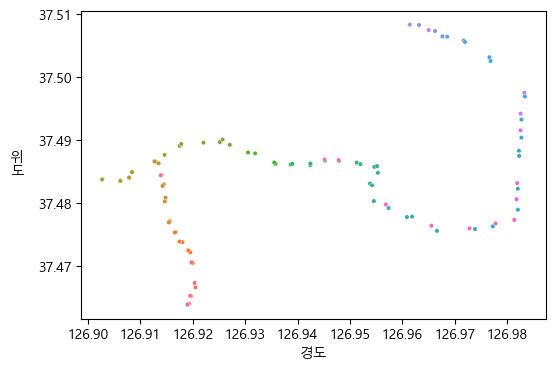

In [177]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

df_station['경도'] = df_station['경도'].astype(float)
df_station['위도'] = df_station['위도'].astype(float)

plt.figure(figsize=(6,4))

ax=sns.scatterplot(data=df_station, x='경도', y='위도', hue='정류소명', s=10, legend=None)

ax.set_ylabel('위\n도', rotation=0, labelpad=15, va='center')
plt.show()

#### 3. busRouteID의 위치 정보 - getBusPosByRtidList 

In [232]:
import requests
import pandas as pd
from dotenv import load_dotenv
from bs4 import BeautifulSoup
from urllib.request import quote
from urllib.request import urlretrieve
import os
load_dotenv()

key = os.getenv('KEY')
busId = 100100260

url3 = 'http://ws.bus.go.kr/api/rest/buspos/getBusPosByRtid?'
params = {'ServiceKey': key,'busRouteId': busId, 'resultType' : 'xml'}

# url3 = f'http://ws.bus.go.kr/api/rest/buspos/getBusPosByRtid?ServiceKey={key}&busRouteId={busId}'
# savefilename3 = 'data/ch14_3.flagInfo.xml'
# urlretrieve(url3, savefilename3)

response = requests.get(url3, params=params)

soup = BeautifulSoup(response.text, 'xml')

itemLists = soup.select('itemList')
len(itemLists)

19

In [236]:
bus_flag = []

for itemList in itemLists:
    congetion = itemList.select_one('congetion').text # 혼잡도(0 : 없음, 3 : 여유, 4 : 보통, 5 : 혼잡)
    congetion = '없음' if congetion=='0' else '여유' if congetion=='3' else '보통' if congetion=='4' else '혼잡'
    nextStTm = itemList.select_one('nextStTm').text
    plainNo = itemList.select_one('plainNo').text
    gpsX = itemList.select_one('gpsX').text
    gpsY = itemList.select_one('gpsY').text
    nextStId = itemList.select_one('nextStId').text
    nexStName = df_station.loc[df_station['ID']==nextStId, '정류소명'].iloc[0]
    lastStnId = itemList.select_one('lastStnId').text
    lastStName = df_station.loc[df_station['ID']==lastStnId, '정류소명'].iloc[0]
    bus_flag.append([plainNo, congetion, lastStName, nexStName, nextStTm, gpsX, gpsY])
    
df_flag = pd.DataFrame(bus_flag, columns=['차량번호','혼잡도','이전정류소','다음정류소','다음정류소도착시간','경도','위도'])
df_flag['다음정류소도착시간'] = round(df_flag['다음정류소도착시간'].astype('int')/60,2)

In [237]:
df_flag

,차량번호,혼잡도,이전정류소,다음정류소,다음정류소도착시간,경도,위도
0,서울74사5286,없음,난곡종점,난곡공영차고지,0.73,126.919167,37.463803
1,서울74사5285,여유,신일교회앞.도깨비시장,신대방역,8.00,126.916821,37.475447
2,서울74사5283,여유,신대방역,조원아파트,1.88,126.912671,37.486572
3,서울74사5282,여유,신림빗물펌프장,신대방역,1.85,126.909569,37.485327
4,서울74사5296,여유,보라매파크뷰아파트,봉원중학교.행운동우성아파트,17.20,126.922535,37.489909
5,서울74사5278,여유,봉일시장,봉원중학교.행운동우성아파트,9.90,126.941548,37.486068
6,서울74사5272,여유,서울대입구역1번출구.샤로수길,중앙대학교,32.28,126.954584,37.480368
7,서울74사5267,여유,남서울농협남현동지점,중앙대학교,25.62,126.976817,37.476478
8,서울74사5259,여유,경문고등학교,중앙대학교,15.07,126.982739,37.490512
9,서울74사5255,여유,중앙대학교,총신대입구역.남성사계시장입구앞,18.13,126.963034,37.509407


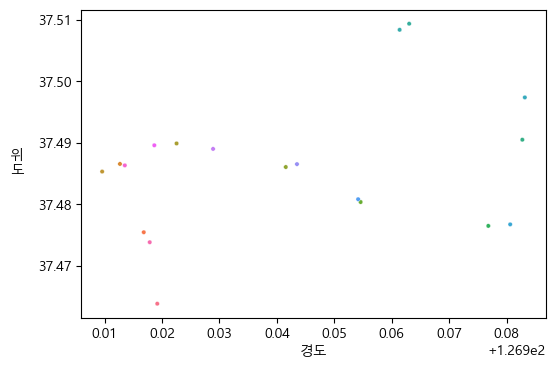

In [235]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

df_flag['경도'] = df_flag['경도'].astype(float)
df_flag['위도'] = df_flag['위도'].astype(float)

plt.figure(figsize=(6,4))

ax=sns.scatterplot(data=df_flag, x='경도', y='위도', hue='차량번호', s=10, legend=None)

ax.set_ylabel('위\n도', rotation=0, labelpad=15, va='center')
plt.show()

# - Quiz 1

In [351]:
import requests
from bs4 import BeautifulSoup

pages = 2
data = []

for page in range(1,pages+1):
    url = f'https://www.yes24.com/product/category/bestseller?categoryNumber=001&pageSize=24&pageNumber={page}'
    savefilename = f'data/ch14_Quiz{page}.html'
    urlretrieve(url,savefilename) 
    
    response = requests.get(url, headers=headers, params=params)
    soup = BeautifulSoup(response.text, 'html.parser')

    rank_els = soup.select('div.img_upper > em.ico.rank')
    book_els = soup.select('div.info_row.info_name > a.gd_name')
    writer_els = soup.select('span.authPub.info_auth')
    publisher_els = soup.select('span.authPub.info_pub > a')
    price_els = soup.select('div.info_row.info_price > strong.txt_num > em.yes_b')

    # writer_els[1].text

    ranks = [int(rank.text) for rank in rank_els]
    books = [book.string for book in book_els]
    writers = [writer.text.strip() for writer in writer_els]
    publishers = [publisher.string for publisher in publisher_els]
    prices = [price.text for price in price_els] 
    
    for n in range(len(writers)):
        if '글' in writers[n]:
            writers[n] = writers[n][:(writers[n].find('글')+1)].strip() 
        elif '저' in writers[n]:
            writers[n] = writers[n][:(writers[n].find('저')+1)].strip()
        else:
            wrtiers[n] = wrtiers[n] 
            
    # writers[6]
    
    for rank, book, writer, publisher, price in zip(ranks, books, writers, publishers, prices):
        data.append({
            '순위' : rank,
            '책 이름' : book,
            '원저/저자/글' : writer,
            '출판사' : publisher,
            '가격' : price+'원'
        })

df = pd.DataFrame(data)
df.to_csv('ch14_yes24_bestseller.csv', index=False)   